# Day 04｜Linear Probe: Can activations reveal sentiment?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HowardHsuuu/mech-interp-ironman-series/blob/main/notebooks/day04_linear_probe.ipynb)

We use **GPT-2 Small**, the **SST-2 sentiment dataset**, and **logistic regression** as a linear probe.

## 1. Setup

Install the libraries used in this experiment. Restarting the runtime is normally unnecessary. The language model will remain frozen throughout the notebook; only the small linear classifier will be trained.

In [1]:
%env PIP_DISABLE_PIP_VERSION_CHECK=1
%pip install -q "transformer-lens==3.8.0" "transformers==5.15.0" "datasets==5.0.1" "scikit-learn==1.9.0" "matplotlib==3.10.8"

env: PIP_DISABLE_PIP_VERSION_CHECK=1


Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
import warnings
from collections.abc import Iterable

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression

from transformer_lens import HookedTransformer

SEED = 42
TRAIN_SIZE = 500
TEST_SIZE = 200
BATCH_SIZE = 64
MAX_LENGTH = 64
PROBE_LAYER = 8
TOKEN_POSITION = "last"
MODEL_NAME = "gpt2-small"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# CPU is the most portable option. Colab users can switch to CUDA automatically.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Matplotlib is building the font cache; this may take a moment.


Using device: cpu


## 2. Load and freeze GPT-2 Small

GPT-2 Small has 12 Transformer blocks and a residual-stream width of 768. We disable gradients for every model parameter so the probe cannot modify the language model.

In [3]:
print("Loading GPT-2 Small with TransformerLens...")
model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model.eval()

for parameter in model.parameters():
    parameter.requires_grad_(False)

n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

print(f"Model: {MODEL_NAME}")
print(f"Transformer blocks: {n_layers}")
print(f"Residual-stream width: {d_model}")
print("GPT-2 parameters frozen:", not any(p.requires_grad for p in model.parameters()))

Loading GPT-2 Small with TransformerLens...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12233.35it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Model: gpt2-small
Transformer blocks: 12
Residual-stream width: 768
GPT-2 parameters frozen: True


## 3. Dataset

We use the SST-2 sentiment dataset from GLUE. Label `0` is negative and label `1` is positive. To keep the experiment friendly to free Colab runtimes, we use a fixed subset of 500 training examples and 200 validation examples.

The validation examples are held out from probe training. We also report the majority-class accuracy instead of assuming the sampled test set is perfectly balanced.

In [4]:
dataset = load_dataset("nyu-mll/glue", "sst2")

train_subset = dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_subset = dataset["validation"].shuffle(seed=SEED).select(range(TEST_SIZE))

train_texts = list(train_subset["sentence"])
test_texts = list(test_subset["sentence"])
y_train = np.asarray(train_subset["label"])
y_test = np.asarray(test_subset["label"])

label_names = {0: "Negative", 1: "Positive"}
majority_baseline = max(np.mean(y_test == 0), np.mean(y_test == 1))

print(f"Train samples: {len(train_texts)}")
print(f"Test samples:  {len(test_texts)}")
print("Train label counts:", {label_names[i]: int(np.sum(y_train == i)) for i in (0, 1)})
print("Test label counts: ", {label_names[i]: int(np.sum(y_test == i)) for i in (0, 1)})
print(f"Majority-class baseline: {majority_baseline:.3f}")
print(f"Example: {train_texts[0]!r} → {label_names[int(y_train[0])]}")

Train samples: 500
Test samples:  200
Train label counts: {'Negative': 210, 'Positive': 290}
Test label counts:  {'Negative': 93, 'Positive': 107}
Majority-class baseline: 0.535
Example: 'klein , charming in comedies like american pie and dead-on in election , ' → Positive


## 4. Extract residual-stream activations

For each sentence, we extract one vector from `blocks.{layer}.hook_resid_post`, the residual stream after a Transformer block. The default representation is taken at the final non-padding token.

GPT-2 uses the same token ID for its beginning/end/padding token in this setup, so token IDs alone cannot reliably identify the final real token. The attention mask keeps that position unambiguous.

In [5]:
def batched(items: list[str], batch_size: int) -> Iterable[list[str]]:
    for start in range(0, len(items), batch_size):
        yield items[start : start + batch_size]


def tokenize_with_attention_mask(texts: list[str]) -> tuple[torch.Tensor, torch.Tensor]:
    tokenizer = model.tokenizer
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    encoded = tokenizer(
        texts,
        add_special_tokens=False,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH - 1,
        return_tensors="pt",
    )

    tokens = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]

    bos_tokens = torch.full(
        (tokens.shape[0], 1), tokenizer.bos_token_id, dtype=tokens.dtype
    )
    bos_mask = torch.ones((attention_mask.shape[0], 1), dtype=attention_mask.dtype)

    tokens = torch.cat([bos_tokens, tokens], dim=1)
    attention_mask = torch.cat([bos_mask, attention_mask], dim=1)
    return tokens.to(device), attention_mask.to(device)


def token_positions(attention_mask: torch.Tensor, position: str | int) -> torch.Tensor:
    if position == "last":
        return attention_mask.sum(dim=1).long() - 1
    if position == "bos":
        return torch.zeros(attention_mask.shape[0], dtype=torch.long, device=device)
    if isinstance(position, int):
        return torch.full((attention_mask.shape[0],), position, dtype=torch.long, device=device)
    raise ValueError("position must be 'last', 'bos', or an integer")


activation_cache: dict[tuple[str, int, str | int], np.ndarray] = {}


def get_activations(
    texts: list[str],
    layer: int,
    *,
    split_name: str,
    position: str | int = TOKEN_POSITION,
) -> np.ndarray:
    cache_key = (split_name, layer, position)
    if cache_key in activation_cache:
        return activation_cache[cache_key]

    hook_name = f"blocks.{layer}.hook_resid_post"
    collected = []

    with torch.inference_mode():
        for batch_texts in batched(texts, BATCH_SIZE):
            tokens, attention_mask = tokenize_with_attention_mask(batch_texts)
            positions = token_positions(attention_mask, position)
            _, cache = model.run_with_cache(
                tokens, names_filter=lambda name: name == hook_name
            )
            batch_indices = torch.arange(tokens.shape[0], device=device)
            selected = cache[hook_name][batch_indices, positions]
            collected.append(selected.detach().cpu())

    activations = torch.cat(collected).numpy()
    activation_cache[cache_key] = activations
    return activations

## 5. Train a probe at one layer

The language model is still frozen. We now train only a logistic-regression classifier on the activations from Layer 8.

In [6]:
X_train = get_activations(train_texts, layer=PROBE_LAYER, split_name="train")
X_test = get_activations(test_texts, layer=PROBE_LAYER, split_name="test")

probe = LogisticRegression(max_iter=1_000, random_state=SEED)
probe.fit(X_train, y_train)

train_accuracy = probe.score(X_train, y_train)
test_accuracy = probe.score(X_test, y_test)

print(f"Hook point: blocks.{PROBE_LAYER}.hook_resid_post")
print(f"Token position: {TOKEN_POSITION} non-padding token")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Train accuracy: {train_accuracy:.3f}")
print(f"Test accuracy:  {test_accuracy:.3f}")
print(f"Baseline:       {majority_baseline:.3f}")
print("GPT-2 parameters frozen:", not any(p.requires_grad for p in model.parameters()))

Hook point: blocks.8.hook_resid_post
Token position: last non-padding token
X_train shape: (500, 768)
X_test shape:  (200, 768)
Train accuracy: 1.000
Test accuracy:  0.785
Baseline:       0.535
GPT-2 parameters frozen: True


## 6. Probe every layer

Repeat the same experiment at every Transformer block. The resulting curve measures how easily sentiment can be linearly decoded at different depths; it does not measure causal importance.

In [7]:
layer_results = []

for layer in range(n_layers):
    X_train_layer = get_activations(train_texts, layer, split_name="train")
    X_test_layer = get_activations(test_texts, layer, split_name="test")

    layer_probe = LogisticRegression(max_iter=1_000, random_state=SEED)
    layer_probe.fit(X_train_layer, y_train)
    accuracy = layer_probe.score(X_test_layer, y_test)
    layer_results.append({"layer": layer, "accuracy": accuracy})
    print(f"Layer {layer:02d}: accuracy = {accuracy:.3f}")

layers = [row["layer"] for row in layer_results]
accuracies = [row["accuracy"] for row in layer_results]
best_index = int(np.argmax(accuracies))
print(f"Best layer: {layers[best_index]} with accuracy {accuracies[best_index]:.3f}")

Layer 00: accuracy = 0.645


Layer 01: accuracy = 0.680


Layer 02: accuracy = 0.615


Layer 03: accuracy = 0.660


Layer 04: accuracy = 0.710


...

Layer 06: accuracy = 0.780


Layer 07: accuracy = 0.775
Layer 08: accuracy = 0.785


Layer 09: accuracy = 0.805


Layer 10: accuracy = 0.770


Layer 11: accuracy = 0.785
Best layer: 9 with accuracy 0.805


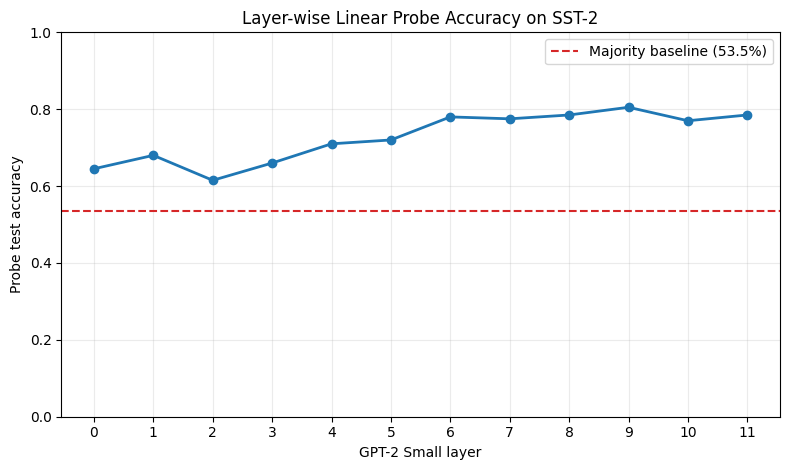

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(layers, accuracies, marker="o", linewidth=2)
ax.axhline(
    majority_baseline,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label=f"Majority baseline ({majority_baseline:.1%})",
)
ax.set(
    title="Layer-wise Linear Probe Accuracy on SST-2",
    xlabel="GPT-2 Small layer",
    ylabel="Probe test accuracy",
    xticks=layers,
    ylim=(0.0, 1.0),
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 7. Try it yourself

Change one thing at a time and rerun the relevant cells:

1. Change `PROBE_LAYER`.
2. Compare `TOKEN_POSITION = "last"` with `"bos"`.
3. Increase `TRAIN_SIZE` or `TEST_SIZE`.
4. Shuffle the training labels as a control.
5. Try a different concept or dataset.
6. Compare the linear probe with a nonlinear classifier.

> If probe accuracy is high, does that mean the model's own later computation uses the information?

Hold that thought. A later experiment will intervene on activations rather than only reading from them.